In [5]:
import warnings
warnings.filterwarnings('ignore')

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)

import torch
import numpy as np
import matplotlib.pyplot as plt
import copy

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)
from ase.units import kB

beta = 1.0 / (kB * 350)

## Loading the models - that is only part of them

In [6]:
# To copy data locally
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is0_28685740/
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl adaptive-350/adaptive-dft/1-adaptive/results_adaptive_is1_28685741/
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is0_28706672
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl adaptive-350/adaptive-dft/2-adaptive-mlp/results_adaptive_is1_28707820
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is0_2946742/is0_flow_dic_training_2946742.pkl adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is0_2946742/
# rsync -av rusty:/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is1_2946741/is1_flow_dic_training_2946741.pkl adaptive-350/adaptive-dft/9-free-energy-data/md_flow_data/results_training_flow_is1_2946741/


In [7]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
DFT_SIMS_PATH = project_path + '/adaptive-350/adaptive-dft'

# ANA
# DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft'

#MARYLOU
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']
adaptive_dft_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']
flow_md_path = ['9-free-energy-data/md_flow_data/results_training_flow_is0_2946742/is0_flow_dic_training_2946742.pkl',
                '9-free-energy-data/md_flow_data/results_training_flow_is1_2946741/is1_flow_dic_training_2946741.pkl']

path_fe = project_path + '/5-FE-comps/0-example'

In [8]:
adaptive_dft_dics = [load_pickle_file('/'+ f, path=DFT_SIMS_PATH) for f in adaptive_dft_path]
adaptive_dft_mlp_dics = [load_pickle_file('/'+ f, path=DFT_SIMS_PATH) for f in adaptive_dft_mlp_path]
md_dics = [load_pickle_file('/'+ f, path=DFT_SIMS_PATH) for f in flow_md_path]

In [9]:
mode_labels = [0, 1]

## Loading the data

In [10]:
dic = {'md_data': '_md', 'flow_mlp_samples' : 'flow_mlp',  
      'flow_dft_samples': 'flow_dft', 'flow_md_samples': 'flow_md', 
      'mcmc_dft_samples': 'mcmc_dft', 'mcmc_mlp_samples': 'mcmc_mlp'}

In [11]:
def load_samples_n_energies(kind, isomer):
    torch_tensor = load_csv_file('is{:d}_{:s}.csv'.format(isomer, dic[kind]),
                  path=project_path + '/data_free_energy')
    return torch_tensor[:, :12], torch_tensor[:, 12]

md_data - 10000 samples
flow_mlp_samples - 10000 samples
flow_dft_samples - 10000 samples
flow_md_samples - 10000 samples
mcmc_dft_samples - 30000 samples
mcmc_mlp_samples - 30000 samples
md_data - 10000 samples
flow_mlp_samples - 10000 samples
flow_dft_samples - 10000 samples
flow_md_samples - 10000 samples
mcmc_dft_samples - 30000 samples
mcmc_mlp_samples - 30000 samples


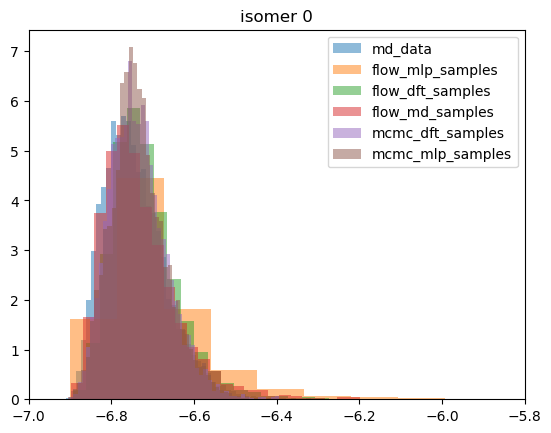

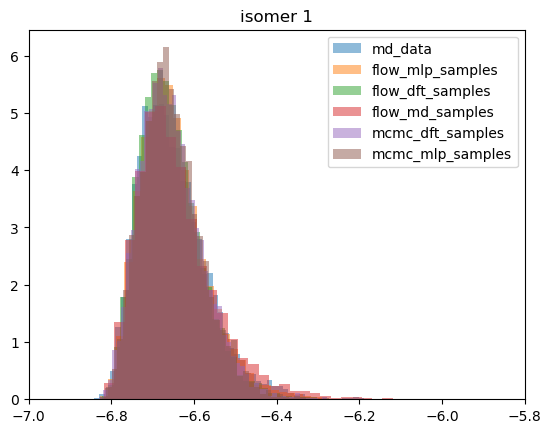

In [12]:
for isomer in mode_labels:
    plt.figure()
    plt.title('isomer {:d}'.format(isomer))
    for kind in dic.keys():
        samples, energies = load_samples_n_energies(kind, isomer)
        print('{:s} - {:d} samples'.format(kind, samples.shape[0]))
        plt.hist(energies, 50, alpha=0.5, label=kind, density=True)
        plt.xlim(-7, -5.8)
    plt.legend()

## 1 - TFEP computations: 

--> We need to also pass the log prob of the flow that generated the samples

In [13]:
isomer_id = 0

# flowmodels -- @ANA: I am not sure this is all the models? is it?
len(adaptive_dft_dics[isomer]['dict_flows_training'][-1][0]['models'])

11

In [14]:
np.linspace(0, len(models)-1, n_training_slice).astype(int)

NameError: name 'models' is not defined

In [ ]:
adaptive_dft_dics[isomer].keys()
len(adaptive_dft_mlp_dics[isomer]['dict_mlps_training'])

31

### 1.1 Flows trained on DFT

Number of dft computed: 10000
Number of dft computed: 10000


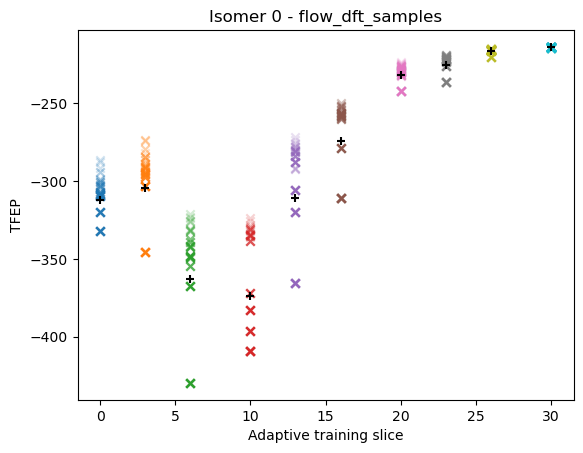

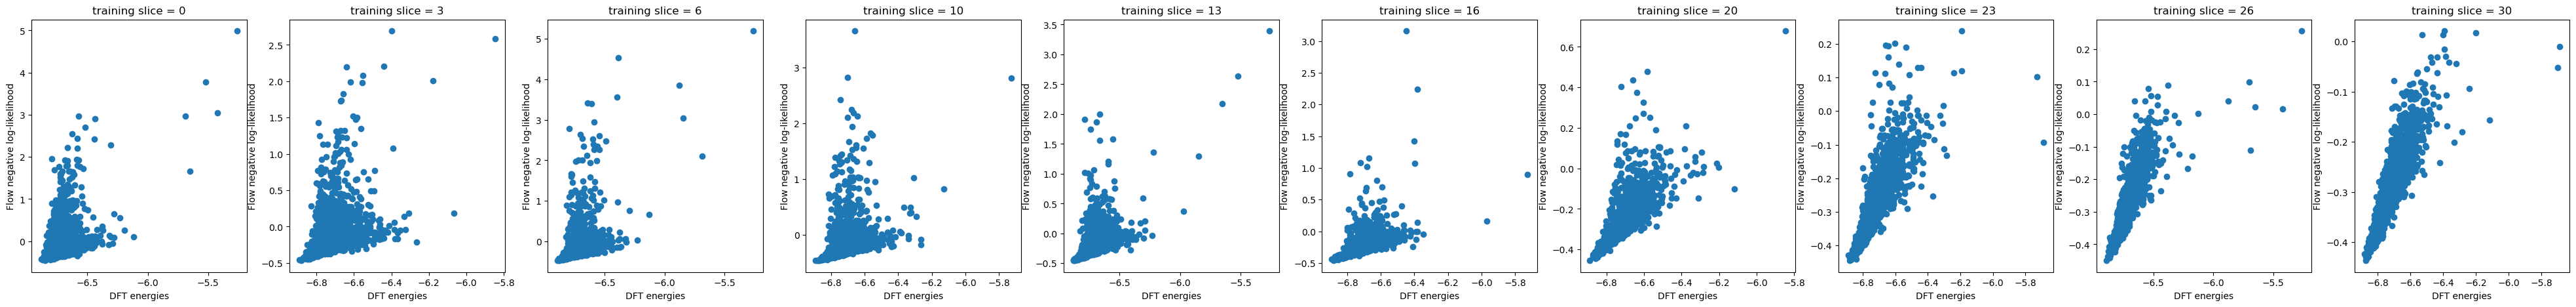

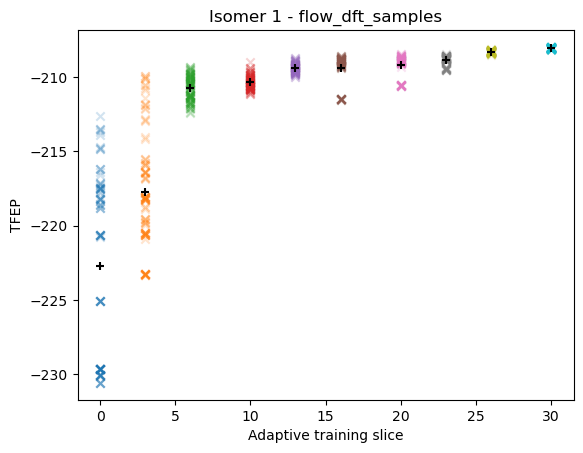

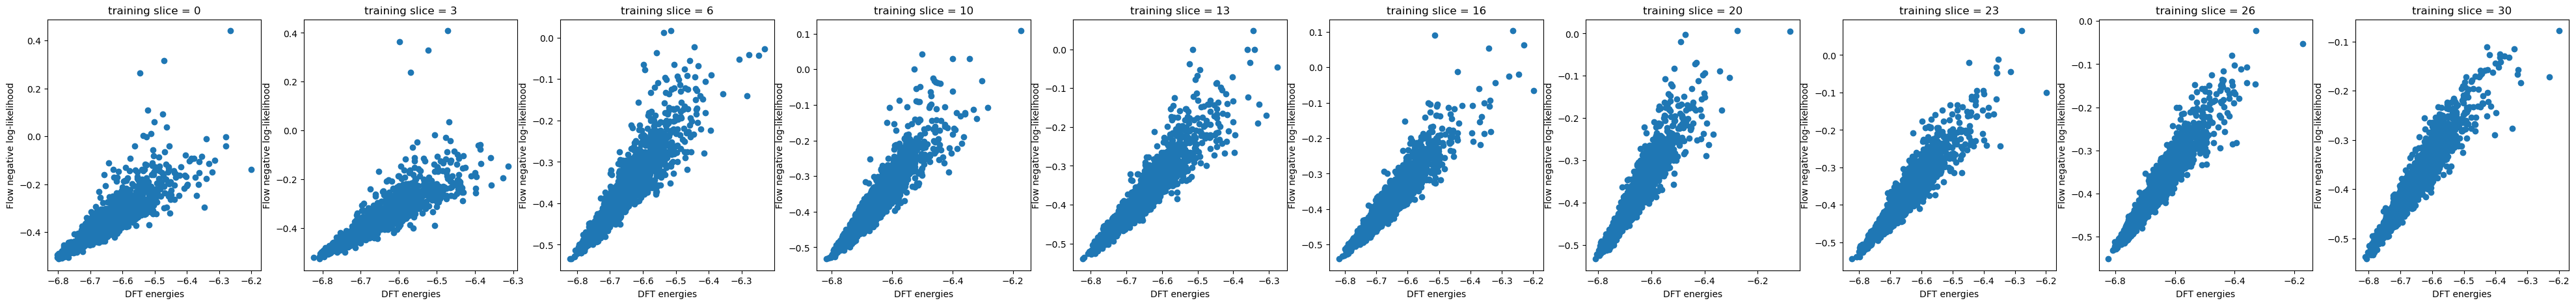

In [20]:
# flow that has been trained by dft 
kind = 'flow_dft_samples'
# Actually here there is an issue - which is that the configurations are generated from the final flow a priori only
n_train_slice = 10
# train_slice = 10
n_samples = 2000


for isomer_id in mode_labels:
    runs = adaptive_dft_dics[isomer_id]['dict_flows_training']
    train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)

    models = [runs[t][0]['models'][-1] for t in train_slices]

    prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed:', energy_target.shape[0])

    dic_results_TFPs = {}

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Adaptive training slice')
    plt.ylabel('TFEP')

    plt.figure(figsize=(5 * n_train_slice, 5))
    axs = [plt.subplot(1, n_train_slice, i+1) for i in range(n_train_slice)]

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []
    dic_results_TFPs[isomer_id]['r_std_fromsum'] = []

    for t, train_slice in enumerate(train_slices):
        log_ratio_0_TFPs = []
        std_r_0_TFPs = []

        for trial in range(100):
            idx = np.random.choice(energy_target.shape[0], n_samples, replace=False)

            logprob_prop = (- models[t].nll(prop_samples[idx])).detach().numpy()
            logprob_target = (- beta * energy_target[idx]).detach().numpy()
            logr_TFP_0, std_r_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            std_r_0_TFPs.append(std_r_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
        dic_results_TFPs[isomer_id]['r_std_fromsum'].append(std_r_0_TFPs)

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*train_slice, log_ratio_0_TFPs, marker='x', alpha=0.2)
        plt.scatter(train_slice, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
        

        plt.sca(axs[t])
        plt.scatter( - logprob_target / beta, - logprob_prop / beta)
        plt.xlabel('DFT energies')
        plt.ylabel('Flow negative log-likelihood')
        plt.title('training slice = {:d}'.format(train_slice))
# for isomer in mode_labels:
#     prop_samples, energy_target = load_samples_n_energies(kind, isomer)

#     logprob_prop =  
#     logprob_target = -energy_target

# compute_TFP_from_samples(logprob_prop, logprob_target)

Number of dft computed: 10000
1.6039519
Number of dft computed: 10000
0.7806566


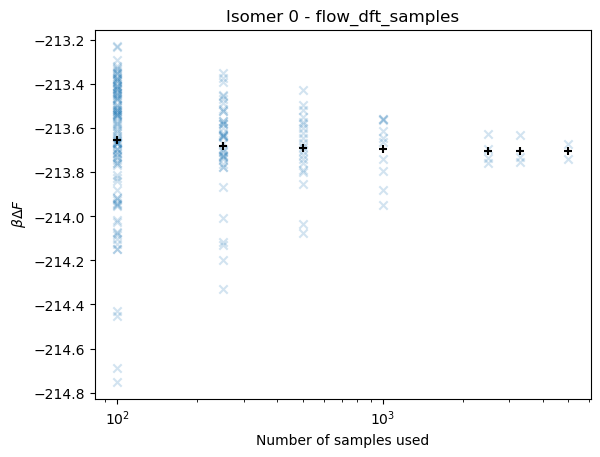

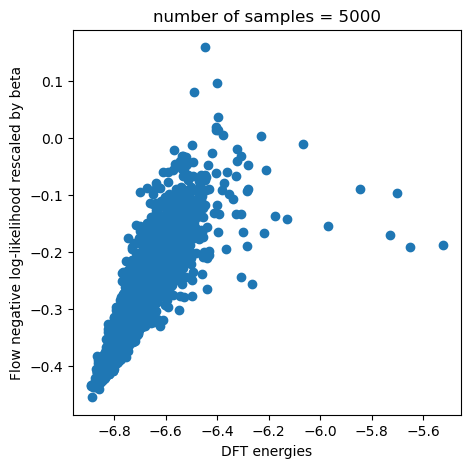

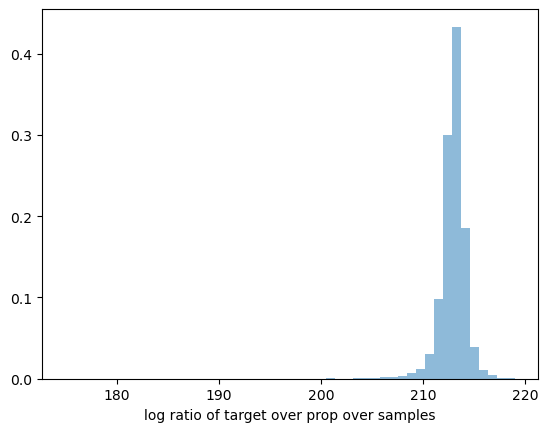

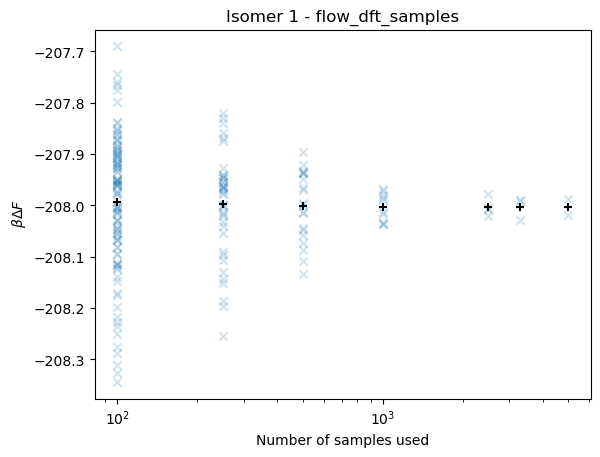

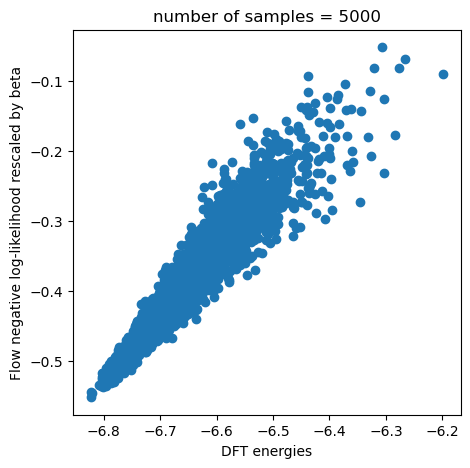

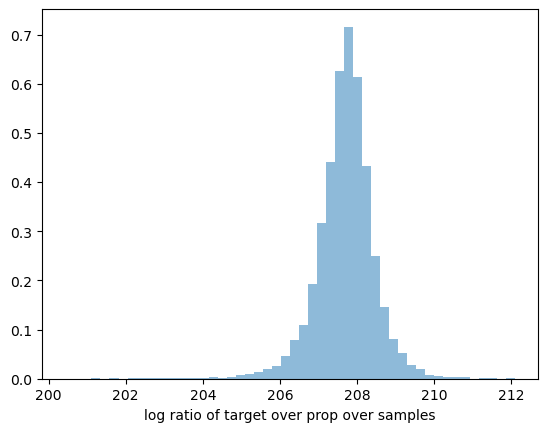

In [22]:
# flow that has been trained by dft 
kind = 'flow_dft_samples'
# Actually here there is an issue - which is that the configurations are generated from the final flow a priori only
# n_train_slice = 10
# train_slice = 10
# n_samples = 2000
n_sampless = np.array([100, 250, 500, 1000, 2500, 3300, 5000]).astype(int)

dic_results_TFPs = {}
for isomer_id in mode_labels:
    runs = adaptive_dft_dics[isomer_id]['dict_flows_training']
    model = runs[-2][0]['models'][-1]

    # train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)
    # models = [runs[t][0]['models'][-1] for t in train_slices]

    prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed:', energy_target.shape[0])

    plt.figure()
    ax1 = plt.subplot(111)
    plt.xscale('log')
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Number of samples used')
    plt.ylabel('TFEP')

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []
    dic_results_TFPs[isomer_id]['stds_logr'] = []

    for nn, n_samples in enumerate(n_sampless):
        log_ratio_0_TFPs = []
        std_r_0_TFPs = []

        n_trial = energy_target.shape[0] // n_samples
        perm = np.random.permutation(energy_target.shape[0])
        for trial in range(n_trial):
            idx = perm[trial*n_samples:(trial+1)*n_samples]

            # logprob_prop = (- models[t].nll(prop_samples[idx])).detach()
            logprob_prop = (- model.nll(prop_samples[idx])).detach().numpy()
            logprob_target = (- beta * energy_target[idx]).detach().numpy()
            logr_TFP_0, std_r_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            std_r_0_TFPs.append(std_r_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
        # dic_results_TFPs[isomer_id]['r_std_fromsum'].append(std_r_0_TFPs)

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*n_samples, log_ratio_0_TFPs, marker='x', c='C0', alpha=0.2)
        plt.scatter(n_samples, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
        plt.ylabel(r' $\beta \Delta F$')    
        
    plt.figure(figsize=(5, 5))
    ax2 = plt.subplot(1,1,1)
    plt.sca(ax2)
    plt.scatter(- logprob_target / beta, - logprob_prop / beta)
    plt.xlabel('DFT energies')
    plt.ylabel('Flow negative log-likelihood rescaled by beta')
    plt.title('number of samples = {:d}'.format(n_samples))
    

    #Trying to estimate/visualize the variance
    n_prop = logprob_prop.shape[0]
    logprob_prop = (- model.nll(prop_samples)).detach()
    logprob_target = (- beta * energy_target).detach()
    logr_per_sample = logprob_target - logprob_prop
    dic_results_TFPs[isomer_id]['stds_logr'] = np.std(logr_per_sample.detach().numpy()) / np.sqrt(n_sampless)

    print(np.std(logr_per_sample.detach().numpy()))
    plt.figure()
    plt.hist(logr_per_sample.detach().numpy(), 50, alpha=0.5, label='logr per sample', density=True)
    plt.xlabel('log ratio of target over prop over samples')

      # max = torch.max(logr_per_sample).item()
    # plt.sca(ax1)
    # plt.plot(n_sampless, np.log(n_sampless)-max, c='k', ls=':', alpha=0.5, label='log(n_samples) - max(logr)')
    # plt.legend()
    


# Saving the result to a make fool plot
dic_results_TFPs_flow_dft = dic_results_TFPs
dic_results_TFPs_flow_dft['n_samples'] = copy.copy(n_sampless)

### 1.2 Flows trained on MD

In [24]:
## NOT SURE WHERE I SHOULD FIND THE PROPER MODELS# md_dics[isomer_id]['model']
# md_dics[0].keys()

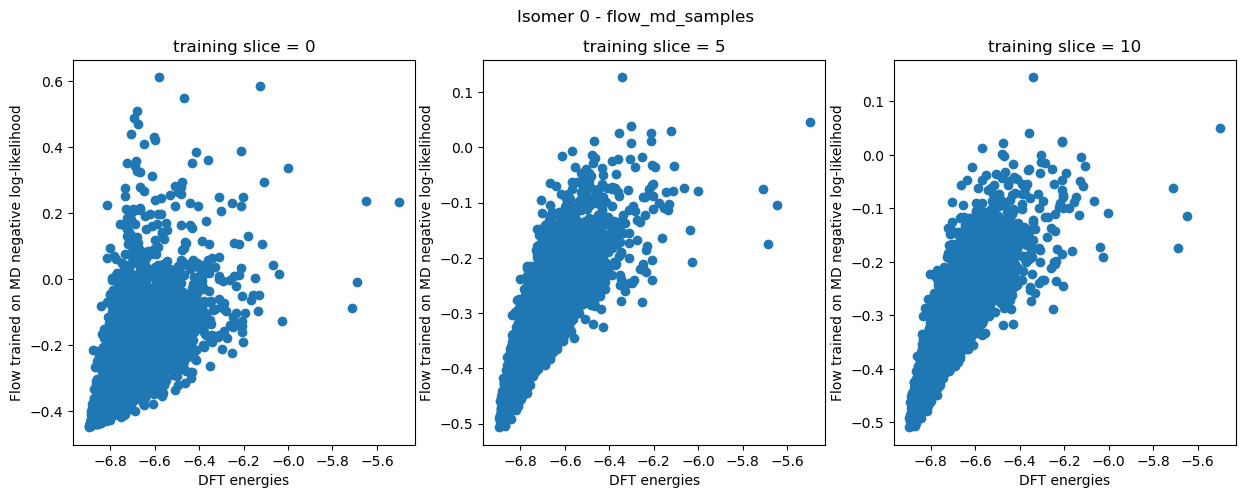

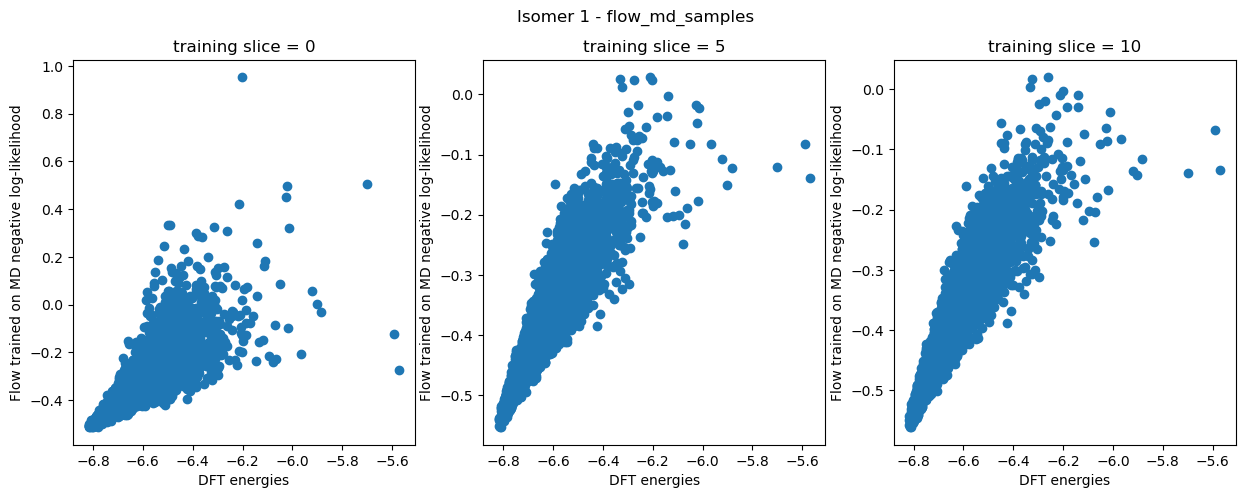

In [25]:
kind = 'flow_md_samples'
n_train_slice = 3
models = md_dics[0]['models']
train_slices = (np.linspace(0, len(models)-1, n_train_slice)).astype(int)

for isomer_id in mode_labels:
        plt.figure(figsize=(5 * n_train_slice, 5))
        plt.suptitle('Isomer {:d} - {:s}'.format(isomer_id, kind))
        axs = [plt.subplot(1, n_train_slice, i+1) for i in range(n_train_slice)]
        # models = load_pickle_file(flow_md_path[isomer_id], path=DFT_SIMS_PATH)['models']
        models = md_dics[isomer_id]['models']
        # len(models)

        prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)

        for t, train_slice in enumerate(train_slices):
                
                model = models[train_slice]
                logprob_prop = (- model.nll(prop_samples)).detach()
                plt.sca(axs[t])
                plt.scatter(energy_target, - logprob_prop / beta  )
                plt.xlabel('DFT energies')
                plt.ylabel('Flow trained on MD negative log-likelihood')
                plt.title('training slice = {:d}'.format(train_slice))

Number of dft computed: 10000
1.7392998
Number of dft computed: 10000
1.4023055


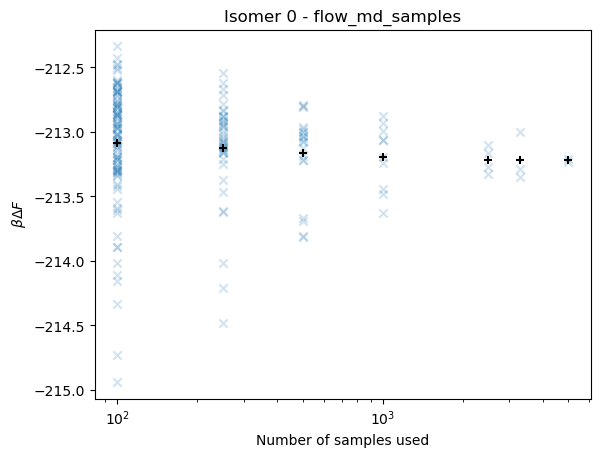

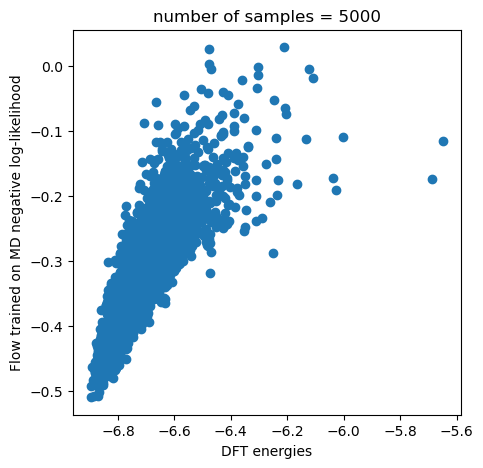

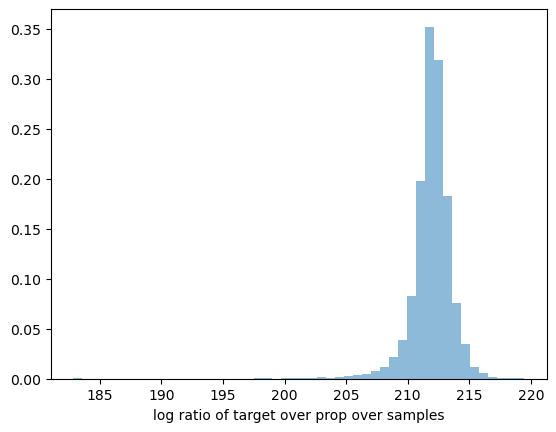

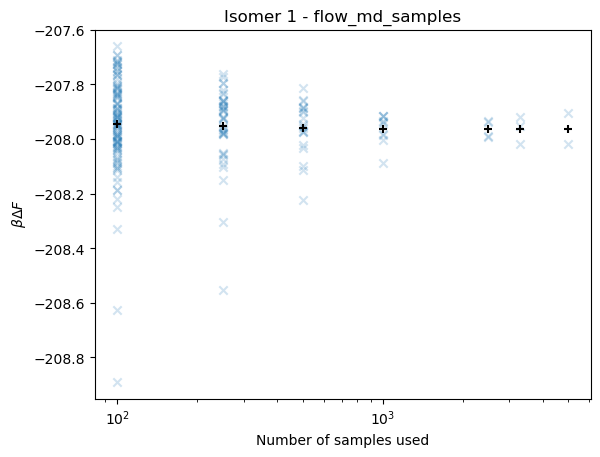

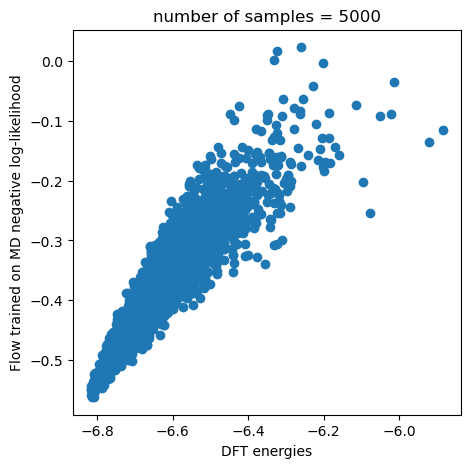

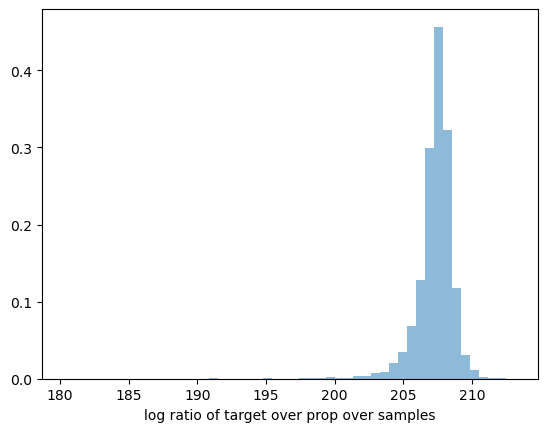

In [26]:
# flow that has been trained by dft 
kind = 'flow_md_samples'
# Actually here there is an issue - which is that the configurations are generated from the final flow a priori only
# n_train_slice = 10
# train_slice = 10
# n_samples = 2000
n_sampless = np.array([100, 250, 500, 1000, 2500, 3300, 5000]).astype(int)

dic_results_TFPs = {}
for isomer_id in mode_labels:
    model = md_dics[isomer_id]['model']

    # train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)
    # models = [runs[t][0]['models'][-1] for t in train_slices]

    prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed:', energy_target.shape[0])

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Number of samples used')
    plt.ylabel(r' $\beta \Delta F$') 
    plt.xscale('log')

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []

    for nn, n_samples in enumerate(n_sampless):
        log_ratio_0_TFPs = []
        log_err_0_TFPs = []

        n_trial = energy_target.shape[0] // n_samples
        perm = np.random.permutation(energy_target.shape[0])
        for trial in range(n_trial):
            idx = perm[trial*n_samples:(trial+1)*n_samples]
            # logprob_prop = (- models[t].nll(prop_samples[idx])).detach()
            logprob_prop = (- model.nll(prop_samples[idx])).detach()
            logprob_target = (- beta * energy_target[idx]).detach()
            logr_TFP_0, log_err_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            log_err_0_TFPs.append(log_err_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*n_samples, log_ratio_0_TFPs, marker='x', c='C0', alpha=0.2)
        plt.scatter(n_samples, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')

        
    plt.figure(figsize=(5, 5))
    ax2 = plt.subplot(1,1,1)
    plt.sca(ax2)
    plt.scatter(- logprob_target / beta, - logprob_prop / beta)
    plt.xlabel('DFT energies')
    plt.ylabel('Flow trained on MD negative log-likelihood')
    plt.title('number of samples = {:d}'.format(n_samples))


   #Trying to estimate/visualize the variance
    n_prop = logprob_prop.shape[0]
    logprob_prop = (- model.nll(prop_samples)).detach()
    logprob_target = (- beta * energy_target).detach()
    logr_per_sample = logprob_target - logprob_prop
    dic_results_TFPs[isomer_id]['stds_logr'] = np.std(logr_per_sample.detach().numpy()) / np.sqrt(n_sampless)

    print(np.std(logr_per_sample.detach().numpy()))
    plt.figure()
    plt.hist(logr_per_sample.detach().numpy(), 50, alpha=0.5, label='logr per sample', density=True)
    plt.xlabel('log ratio of target over prop over samples')

      # max = torch.max(logr_per_sample).item()
    # plt.sca(ax1)
    # plt.plot(n_sampless, np.log(n_sampless)-max, c='k', ls=':', alpha=0.5, label='log(n_samples) - max(logr)')
    # plt.legend()
    

# Saving for combined plot
dic_results_TFPs_flow_md = dic_results_TFPs
dic_results_TFPs_flow_md['n_samples'] = n_sampless

#### Outliers that show up as log_n + constant 

(array([6.83620490e-02, 2.38434664e-02, 9.35569901e-03, 1.83549452e-02,
        2.30467620e-02, 4.52154407e-03, 5.32249018e-03, 4.17687724e-03,
        0.00000000e+00, 8.57440791e-04, 1.34577042e-03, 0.00000000e+00,
        8.28790306e-04, 6.50401456e-04, 5.10409027e-04, 2.00274286e-04,
        1.57167243e-04, 0.00000000e+00, 9.67911655e-05]),
 array([  10.        ,   12.74274986,   16.23776739,   20.69138081,
          26.36650899,   33.59818286,   42.81332399,   54.55594781,
          69.51927962,   88.58667904,  112.88378917,  143.84498883,
         183.29807108,  233.57214691,  297.63514416,  379.26901907,
         483.29302386,  615.84821107,  784.75997035, 1000.        ]),
 <BarContainer object of 19 artists>)

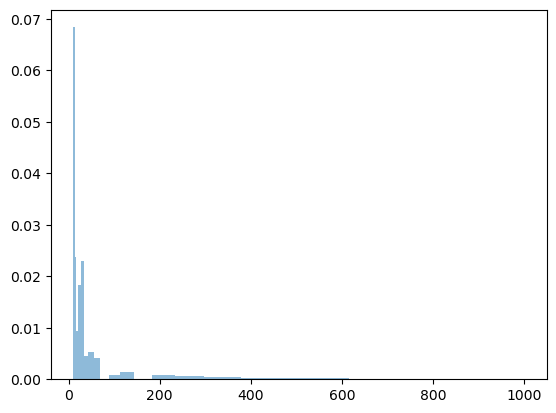

In [ ]:

isomer_id = 0
model = md_dics[isomer_id]['model']

# train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)
# models = [runs[t][0]['models'][-1] for t in train_slices]
prop_samples, energy_target = load_samples_n_energies(kind, isomer_id) 
n_prop = prop_samples.shape[0]
log_prob_target = -energy_target
log_prob_prop = (- model.nll(prop_samples)).detach()
logr_per_sample = logprob_target - logprob_prop
# logr = - logsumexp(logr_per_sample) + np.log(n_prop)
bins = np.logspace(1, 3, 20)
plt.hist(np.exp(logr_per_sample),bins=bins, alpha=0.5, label=kind, density=True)

### 1.3 Flows trained on DFT+MLP 

In [15]:
len(adaptive_dft_mlp_dics[isomer_id]['dict_flows_training'][-2]) #[-2][1]
# adaptive_dft_mlp_dics[isomer_id].keys()
# [0]['dict_flows_training'][0][0].keys()
print(len(adaptive_dft_mlp_dics[isomer_id]['dict_mlps_training']), 'training slices')
mlp_model = adaptive_dft_mlp_dics[isomer_id]['dict_mlps_training'][-1][0]['model']

31 training slices


31 models
31 models


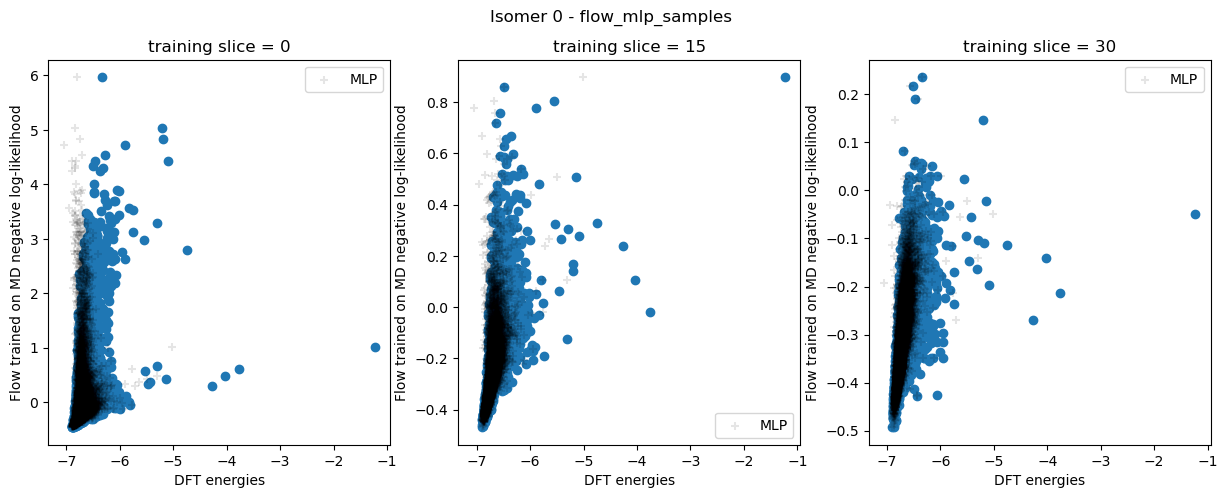

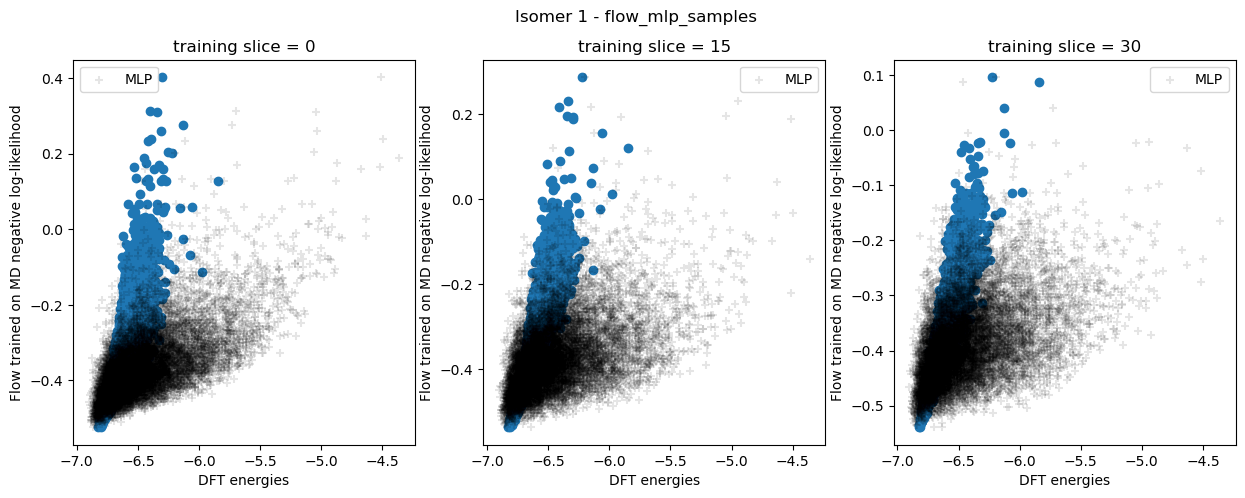

In [27]:
kind = 'flow_mlp_samples'
n_train_slice = 3


for isomer_id in mode_labels:
        plt.figure(figsize=(5 * n_train_slice, 5))
        plt.suptitle('Isomer {:d} - {:s}'.format(isomer_id, kind))
        axs = [plt.subplot(1, n_train_slice, i+1) for i in range(n_train_slice)]
        
        models = [model_list[0]['model'] for model_list in adaptive_dft_mlp_dics[isomer_id]['dict_flows_training']]
        print('{:d} models'.format(len(models)))
        train_slices = (np.linspace(0, len(models)-1, n_train_slice)).astype(int)

        prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
        mlp_energies = mlp_model(prop_samples).detach().numpy()

        for t, train_slice in enumerate(train_slices):
                
                model = models[train_slice]
                logprob_prop = (- model.nll(prop_samples)).detach()
                plt.sca(axs[t])
                plt.scatter(energy_target, - logprob_prop / beta)
                plt.scatter(mlp_energies, - logprob_prop / beta, c='k', marker='+', label='MLP', alpha=0.1)
                plt.xlabel('DFT energies')
                plt.ylabel('Flow trained on MD negative log-likelihood')
                plt.title('training slice = {:d}'.format(train_slice))
                plt.legend()

Number of dft computed: 10000
3.7533011
Number of dft computed: 10000
1.0465446


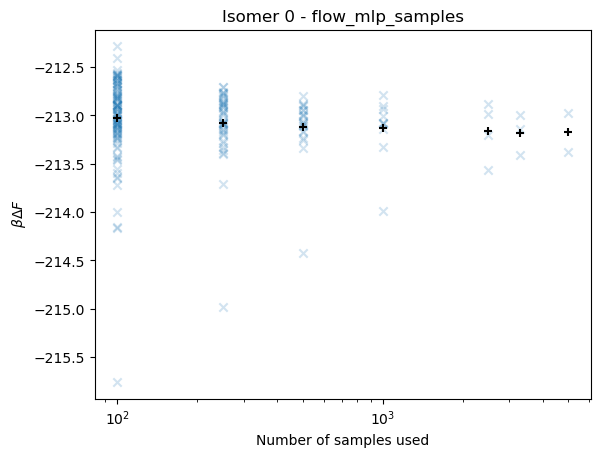

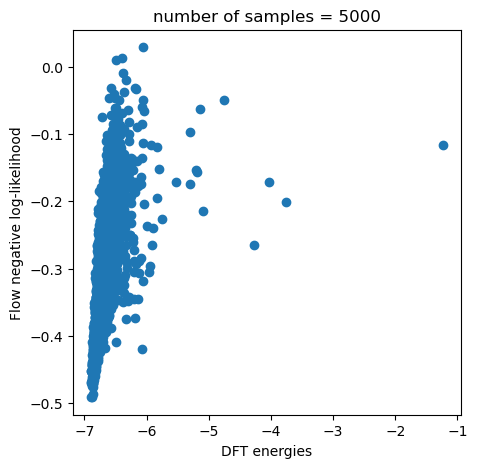

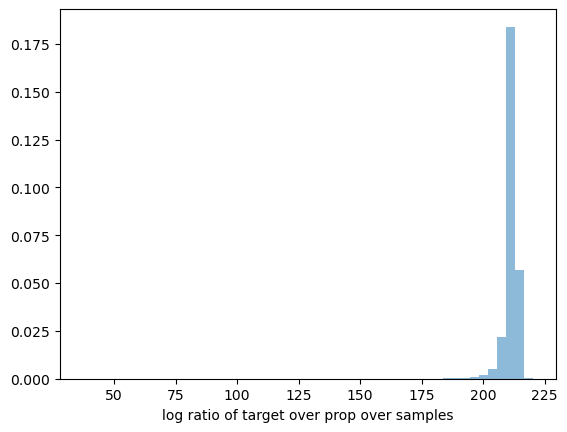

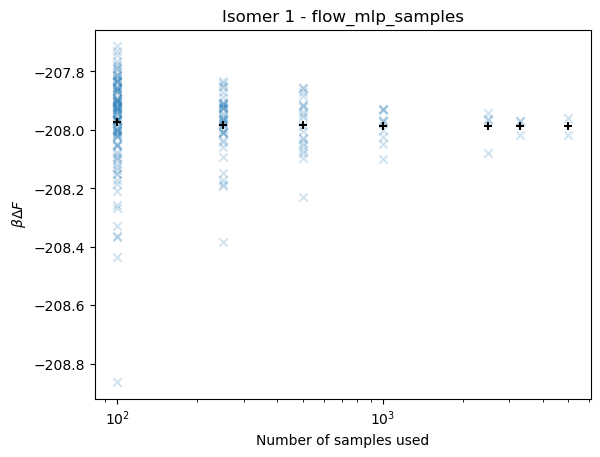

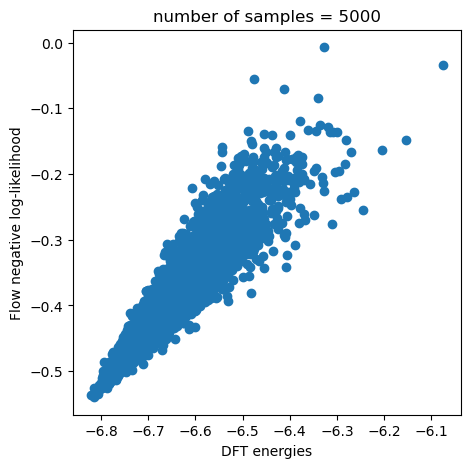

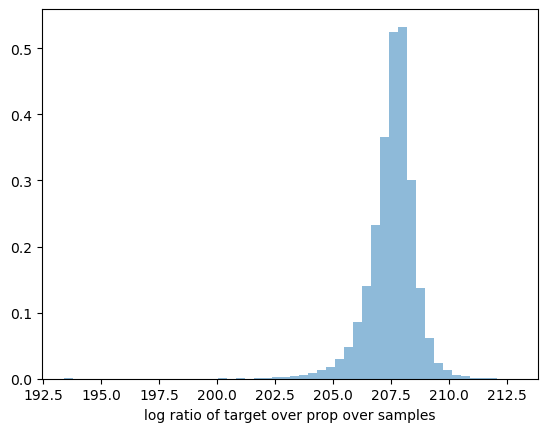

In [28]:
# flow that has been trained by dft 
kind = 'flow_mlp_samples'

n_sampless = np.array([100, 250, 500, 1000, 2500, 3300, 5000]).astype(int)

dic_results_TFPs = {}
for isomer_id in mode_labels:
    model = adaptive_dft_mlp_dics[isomer_id]['dict_flows_training'][-2][0]['model']

    # train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)
    # models = [runs[t][0]['models'][-1] for t in train_slices]

    prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed:', energy_target.shape[0])

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Number of samples used')
    plt.ylabel(r' $\beta \Delta F$') 
    plt.xscale('log')

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []
    dic_results_TFPs[isomer_id]['stds_logr'] = []

    for nn, n_samples in enumerate(n_sampless):
        log_ratio_0_TFPs = []
        std_r_0_TFPs = []

        n_trial = energy_target.shape[0] // n_samples
        perm = np.random.permutation(energy_target.shape[0])
        for trial in range(n_trial):
            idx = perm[trial*n_samples:(trial+1)*n_samples]

            # logprob_prop = (- models[t].nll(prop_samples[idx])).detach()
            logprob_prop = (- model.nll(prop_samples[idx])).detach().numpy()
            logprob_target = (- beta * energy_target[idx]).detach().numpy()
            logr_TFP_0, std_r_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            std_r_0_TFPs.append(std_r_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
        # dic_results_TFPs[isomer_id]['r_std_fromsum'].append(std_r_0_TFPs)

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*n_samples, log_ratio_0_TFPs, marker='x', c='C0', alpha=0.2)
        plt.scatter(n_samples, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
        
    plt.figure(figsize=(5, 5))
    ax2 = plt.subplot(1,1,1)
    plt.sca(ax2)
    plt.scatter(-logprob_target/beta, -logprob_prop/beta)
    plt.xlabel('DFT energies')
    plt.ylabel('Flow negative log-likelihood')
    plt.title('number of samples = {:d}'.format(n_samples))

    #Trying to estimate/visualize the variance
    n_prop = logprob_prop.shape[0]
    logprob_prop = (- model.nll(prop_samples)).detach()
    logprob_target = (- beta * energy_target).detach()
    logr_per_sample = logprob_target - logprob_prop
    dic_results_TFPs[isomer_id]['stds_logr'] = np.std(logr_per_sample.detach().numpy()) / np.sqrt(n_sampless)

    print(np.std(logr_per_sample.detach().numpy()))
    plt.figure()
    plt.hist(logr_per_sample.detach().numpy(), 50, alpha=0.5, label='logr per sample', density=True)
    plt.xlabel('log ratio of target over prop over samples')


# Saving the result to a make fool plot
dic_results_TFPs_flow_dft_mlp = dic_results_TFPs
dic_results_TFPs_flow_dft_mlp['n_samples'] = copy.copy(n_sampless)

#TODO: compare with the estimate with the MLP energy

4.0924687
11.078207


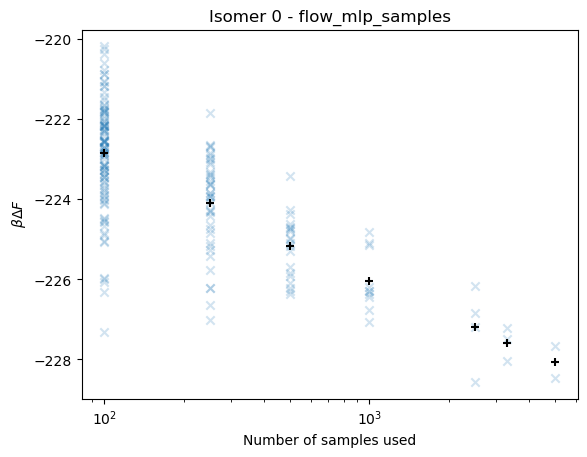

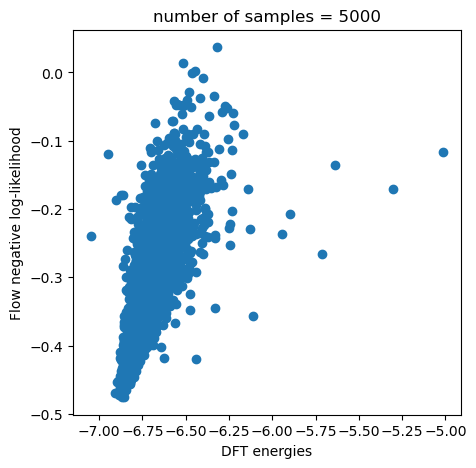

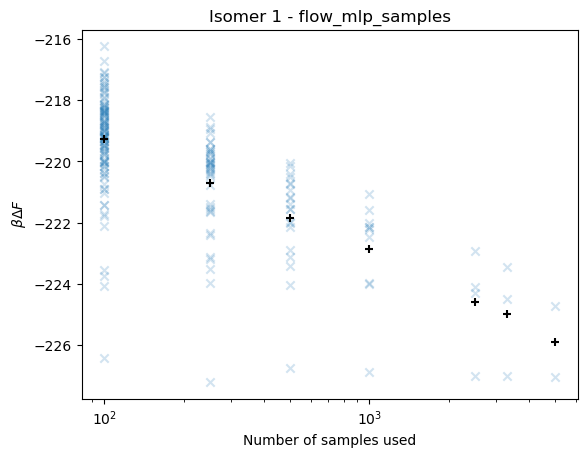

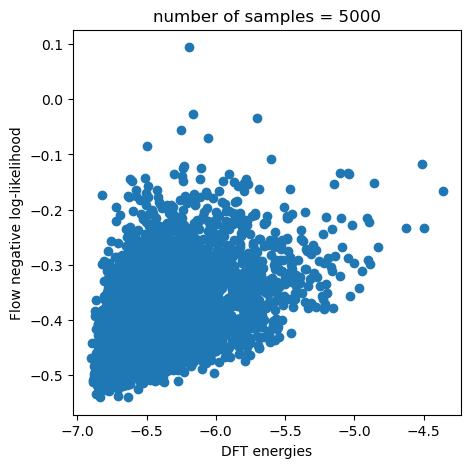

In [29]:
# flow that has been trained by dft 
kind = 'flow_mlp_samples'

n_sampless = np.array([100, 250, 500, 1000, 2500, 3300, 5000]).astype(int)

dic_results_TFPs = {}
for isomer_id in mode_labels:
    model = adaptive_dft_mlp_dics[isomer_id]['dict_flows_training'][-2][0]['model']

    # train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)
    # models = [runs[t][0]['models'][-1] for t in train_slices]

    prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
    energy_target = mlp_model(prop_samples).detach()

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Number of samples used')
    plt.ylabel(r' $\beta \Delta F$') 
    plt.xscale('log')

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []
    dic_results_TFPs[isomer_id]['stds_logr'] = []

    for nn, n_samples in enumerate(n_sampless):
        log_ratio_0_TFPs = []
        std_r_0_TFPs = []

        n_trial = energy_target.shape[0] // n_samples
        perm = np.random.permutation(energy_target.shape[0])
        for trial in range(n_trial):
            idx = perm[trial*n_samples:(trial+1)*n_samples]

            # logprob_prop = (- models[t].nll(prop_samples[idx])).detach()
            logprob_prop = (- model.nll(prop_samples[idx])).detach().numpy()
            logprob_target = (- beta * energy_target[idx]).detach().numpy()
            logr_TFP_0, std_r_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            std_r_0_TFPs.append(std_r_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
        # dic_results_TFPs[isomer_id]['r_std_fromsum'].append(std_r_0_TFPs)

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*n_samples, log_ratio_0_TFPs, marker='x', c='C0', alpha=0.2)
        plt.scatter(n_samples, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
        
    plt.figure(figsize=(5, 5))
    ax2 = plt.subplot(1,1,1)
    plt.sca(ax2)
    plt.scatter(-logprob_target/beta, -logprob_prop/beta)
    plt.xlabel('DFT energies')
    plt.ylabel('Flow negative log-likelihood')
    plt.title('number of samples = {:d}'.format(n_samples))

    #Trying to estimate/visualize the variance
    n_prop = logprob_prop.shape[0]
    logprob_prop = (- model.nll(prop_samples)).detach()
    logprob_target = (- beta * energy_target).detach()
    logr_per_sample = logprob_target - logprob_prop
    dic_results_TFPs[isomer_id]['stds_logr'] = np.std(logr_per_sample.detach().numpy()) / np.sqrt(n_sampless)

    print(np.std(logr_per_sample.detach().numpy()))
    # plt.figure()
    # plt.hist(logr_per_sample.detach().numpy(), 50, alpha=0.5, label='logr per sample', density=True)
    # plt.xlabel('log ratio of target over prop over samples')


# Saving the result to a make fool plot
dic_results_TFPs_flow_dft_mlp_target_mlp = dic_results_TFPs
dic_results_TFPs_flow_dft_mlp_target_mlp['n_samples'] = copy.copy(n_sampless)

### 1.z Combining the plots

Text(0, 0.5, 'Ratio of partition functions')

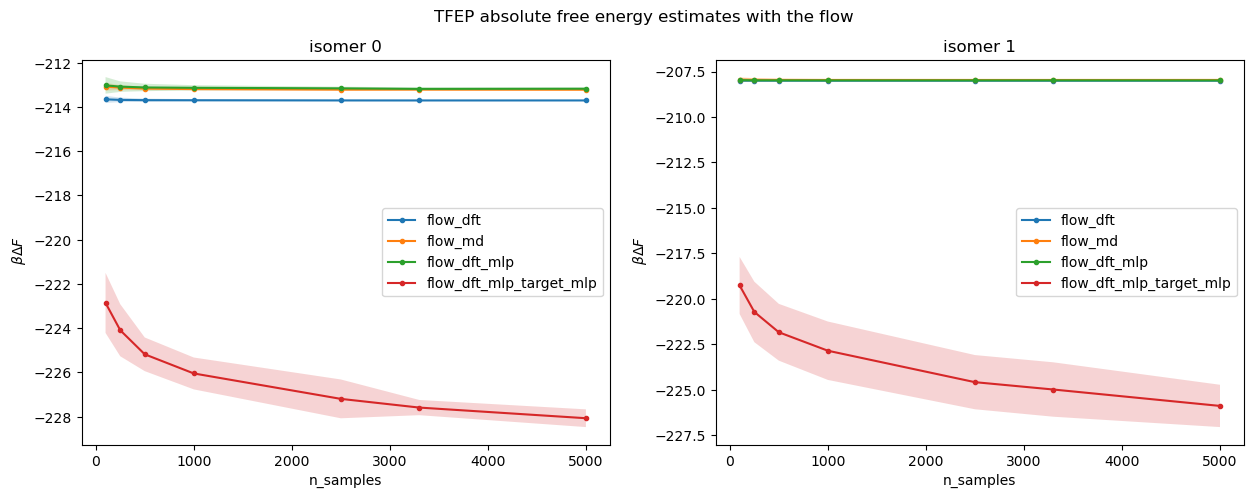

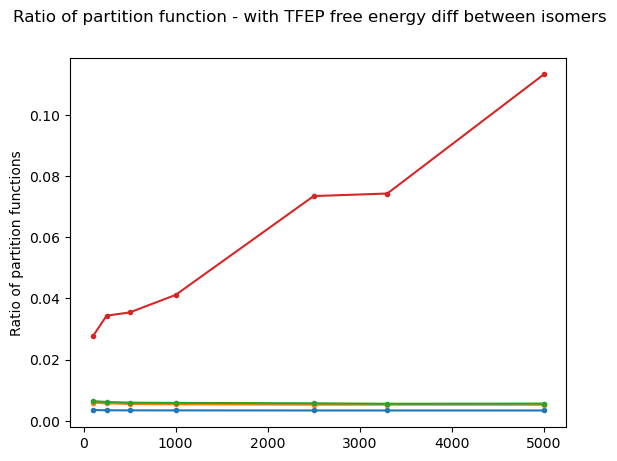

In [31]:
dic_results_TFPs_flow_dft
dic_results_TFPs_flow_md

plt.figure(figsize=(15, 5))
plt.suptitle('TFEP absolute free energy estimates with the flow')
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
for isomer_id in mode_labels:
    plt.sca(axs[isomer_id])
    plt.title('isomer {:d}'.format(isomer_id))

    ############################
    plt.plot(dic_results_TFPs_flow_dft['n_samples'],
                dic_results_TFPs_flow_dft[isomer_id]['means'],  '.-',
                label='flow_dft')
    # plt.fill_between(dic_results_TFPs_flow_dft['n_samples'],
    #                 np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) - np.array(dic_results_TFPs_flow_dft[isomer_id]['']),
    #                 np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) + np.array(dic_results_TFPs_flow_dft[isomer_id]['stds']),
    #                 alpha=0.2)
    plt.fill_between(dic_results_TFPs_flow_dft['n_samples'],
                    np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) - np.array(dic_results_TFPs_flow_dft[isomer_id]['stds_logr']),
                    np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) + np.array(dic_results_TFPs_flow_dft[isomer_id]['stds_logr']),
                    alpha=0.2)
    ############################
    plt.plot(dic_results_TFPs_flow_md['n_samples'], 
                dic_results_TFPs_flow_md[isomer_id]['means'], '.-',
                label='flow_md')
    
    plt.fill_between(dic_results_TFPs_flow_md['n_samples'],
                    np.array(dic_results_TFPs_flow_md[isomer_id]['means']) - np.array(dic_results_TFPs_flow_md[isomer_id]['stds_logr']),
                    np.array(dic_results_TFPs_flow_md[isomer_id]['means']) + np.array(dic_results_TFPs_flow_md[isomer_id]['stds_logr']),
                    alpha=0.2)
    
    ############################
    plt.plot(dic_results_TFPs_flow_dft_mlp['n_samples'],
                dic_results_TFPs_flow_dft_mlp[isomer_id]['means'],  '.-',
                label='flow_dft_mlp')
    
    plt.fill_between(dic_results_TFPs_flow_dft_mlp['n_samples'],
                    np.array(dic_results_TFPs_flow_dft_mlp[isomer_id]['means']) - np.array(dic_results_TFPs_flow_dft_mlp[isomer_id]['stds_logr']),
                    np.array(dic_results_TFPs_flow_dft_mlp[isomer_id]['means']) + np.array(dic_results_TFPs_flow_dft_mlp[isomer_id]['stds_logr']),
                    alpha=0.2)
    
    ############################
    plt.plot(dic_results_TFPs_flow_dft_mlp_target_mlp['n_samples'],
                dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['means'],  '.-',
                label='flow_dft_mlp_target_mlp')
    
    plt.fill_between(dic_results_TFPs_flow_dft_mlp_target_mlp['n_samples'],
                    np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['means']) - np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['stds']),
                    np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['means']) + np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['stds']),
                    alpha=0.2)

    plt.legend()
    plt.xlabel('n_samples')
    plt.ylabel(r' $\beta \Delta F$') 
    

plt.figure()
plt.suptitle('Ratio of partition function - with TFEP free energy diff between isomers')
plt.plot(dic_results_TFPs_flow_dft['n_samples'],
            np.exp( np.array(dic_results_TFPs_flow_dft[0]['means']) - np.array(dic_results_TFPs_flow_dft[1]['means'])),  '.-',
            label='flow_dft')
plt.plot(dic_results_TFPs_flow_md['n_samples'],
            np.exp( np.array(dic_results_TFPs_flow_md[0]['means']) - np.array(dic_results_TFPs_flow_md[1]['means'])),  '.-',
            label='flow_md')
plt.plot(dic_results_TFPs_flow_dft_mlp['n_samples'],
            np.exp( np.array(dic_results_TFPs_flow_dft_mlp[0]['means']) - np.array(dic_results_TFPs_flow_dft_mlp[1]['means'])),  '.-',
            label='flow_dft_mlp')
plt.plot(dic_results_TFPs_flow_dft_mlp_target_mlp['n_samples'],
            np.exp(np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[0]['means']) - np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[1]['means'])),  '.-',
            label='flow_dft_mlp_target_mlp')
plt.ylabel('Ratio of partition functions')

## 2 - BAR computations

### 2.1 MD samples and MD trained flow

In [149]:
kind = 'flow_md_samples'
# MCMC samples + dft flow VS MD samples + md flow
model = md_dics[isomer_id]['model']
prop_samples, prop_energy_target = load_samples_n_energies(kind, isomer_id)
print('Number of dft computed for proposal:', energy_target.shape[0])

kind = 'md_data'
mc_samples, mc_energy_target = load_samples_n_energies(kind, isomer_id)
print('Number of dft computed for MD:', energy_target.shape[0])

prop = model

logprop_prop = - prop.nll(prop_samples).detach().numpy() 
logprop_mc = - prop.nll(mc_samples).detach().numpy() 
logtgt_prop = - beta * prop_energy_target.detach().numpy()
logtgt_mc = - beta * mc_energy_target.detach().numpy()


logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
                             maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)

Number of dft computed for proposal: 10000
Number of dft computed for MD: 10000


Number of dft computed for proposal: 10000
Number of dft computed for MD: 10000
Number of dft computed for proposal: 10000
Number of dft computed for MD: 10000


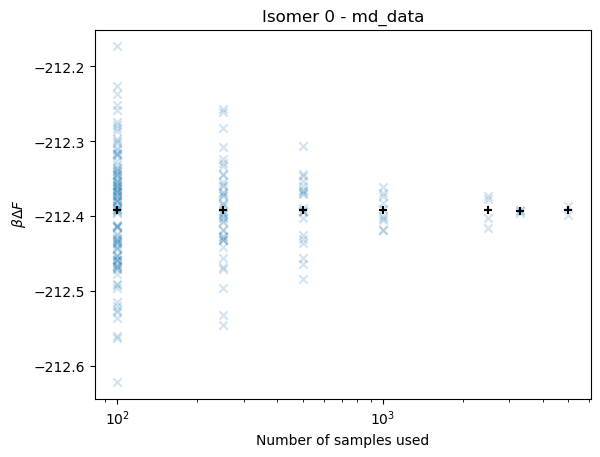

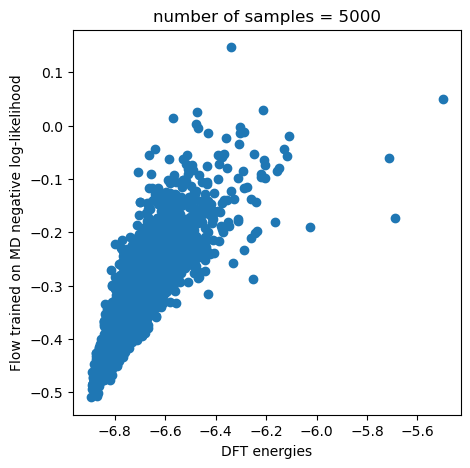

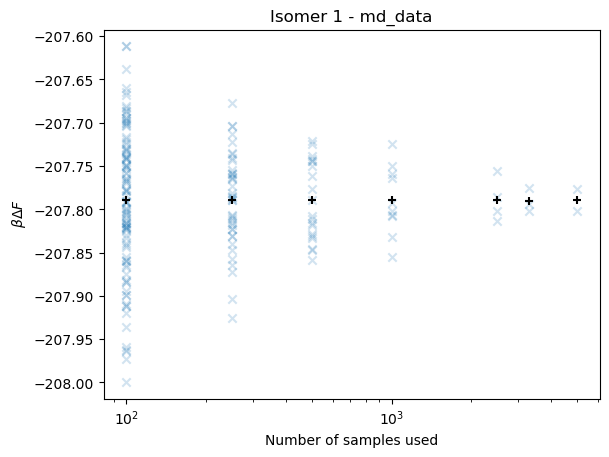

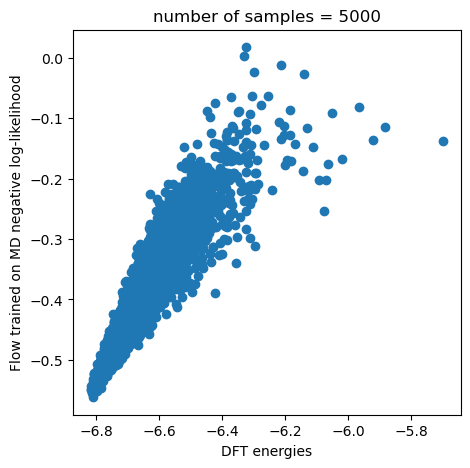

In [162]:
# flow that has been trained by MD 

n_sampless = np.array([100, 250, 500, 1000, 2500, 3300, 5000]).astype(int)

dic_results_BARs = {}
for isomer_id in mode_labels:
    kind = 'flow_md_samples'
    model = md_dics[isomer_id]['model']
    prop_samples, prop_energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed for proposal:', energy_target.shape[0])

    kind = 'md_data'
    mc_samples, mc_energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed for MD:', energy_target.shape[0])

    prop = model

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Number of samples used')
    plt.ylabel(r' $\beta \Delta F$') 
    plt.xscale('log')

    dic_results_BARs[isomer_id] = {}
    dic_results_BARs[isomer_id]['means'] = []
    dic_results_BARs[isomer_id]['stds'] = []

    for nn, n_samples in enumerate(n_sampless):
        log_ratio_0_BARs = []
        log_err_0_BARs = []

        n_trial = energy_target.shape[0] // n_samples
        perm = np.random.permutation(energy_target.shape[0])
        for trial in range(n_trial):
            idx = perm[trial*n_samples:(trial+1)*n_samples]
            logprop_prop = - prop.nll(prop_samples[idx]).detach().numpy() 
            logprop_mc = - prop.nll(mc_samples[idx]).detach().numpy() 
            logtgt_prop = - beta * prop_energy_target[idx].detach().numpy()
            logtgt_mc = - beta * mc_energy_target[idx].detach().numpy()


            logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
                                        maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
            log_ratio_0_BARs.append(logr)
            log_err_0_BARs.append(logr_err)

            
        dic_results_BARs[isomer_id]['means'].append(np.array(log_ratio_0_BARs).mean())
        dic_results_BARs[isomer_id]['stds'].append(np.array(log_ratio_0_BARs).std())

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_BARs))*n_samples, log_ratio_0_BARs, marker='x', c='C0', alpha=0.2)
        plt.scatter(n_samples, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')

        
    plt.figure(figsize=(5, 5))
    ax2 = plt.subplot(1,1,1)
    plt.sca(ax2)
    plt.scatter(- logtgt_prop / beta, - logprop_prop / beta)
    plt.xlabel('DFT energies')
    plt.ylabel('Flow trained on MD negative log-likelihood')
    plt.title('number of samples = {:d}'.format(n_samples))


    # max = torch.max(logr_per_sample).item()
    # plt.sca(ax1)
    # plt.plot(n_sampless, np.log(n_sampless)-max, c='k', ls=':', alpha=0.5, label='log(n_samples) - max(logr)')
    # plt.legend()
    

# Saving for combined plot
dic_results_BARs_flow_md = dic_results_BARs
dic_results_BARs_flow_md['n_samples'] = n_sampless

### 2.2 MCMC samples and adaptively trained flow

In [145]:
runs = adaptive_dft_dics[isomer_id]['dict_flows_training']
model = runs[-2][0]['models'][-1]

kind = 'flow_dft_samples'

prop_samples, prop_energy_target = load_samples_n_energies(kind, isomer_id)
print('Number of dft computed for proposal:', prop_energy_target.shape[0])

kind = 'mcmc_dft_samples'
mc_samples, mc_energy_target = load_samples_n_energies(kind, isomer_id)
print('Number of dft computed for adpative MCMC:', mc_energy_target.shape[0])

prop = model

logprop_prop = - prop.nll(prop_samples).detach().numpy() 
logprop_mc = - prop.nll(mc_samples).detach().numpy() 
logtgt_prop = - prop_energy_target.detach().numpy()
logtgt_mc = - mc_energy_target.detach().numpy()


logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
                             maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)

Number of dft computed for proposal: 10000
Number of dft computed for MD: 10000


Number of dft computed for proposal: 10000
Number of dft computed for proposal: 10000
Number of dft computed for adpative MCMC: 10000
Number of dft computed for proposal: 10000
Number of dft computed for proposal: 30000
Number of dft computed for adpative MCMC: 10000


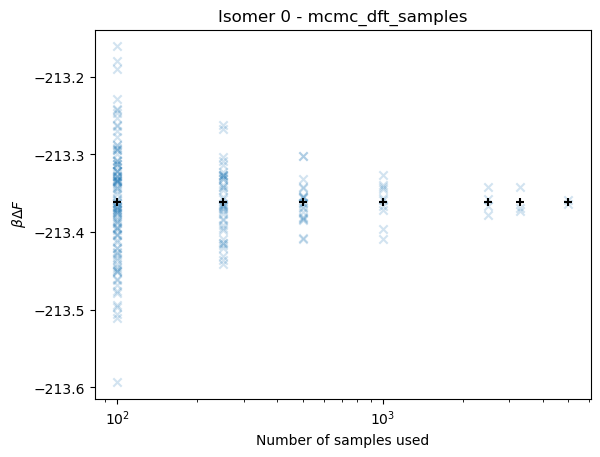

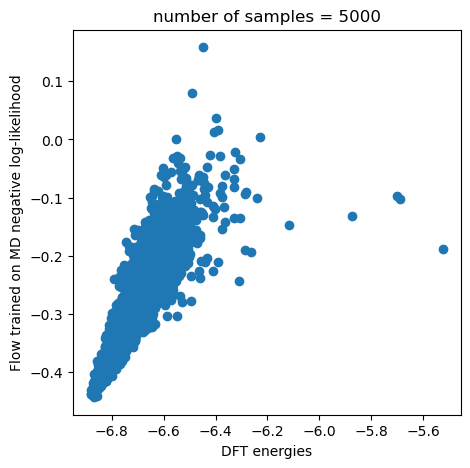

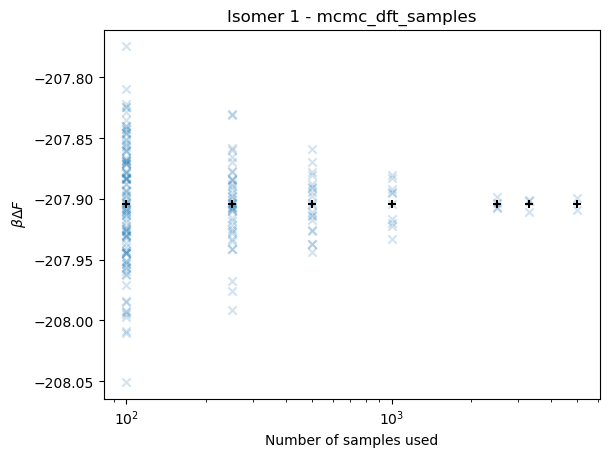

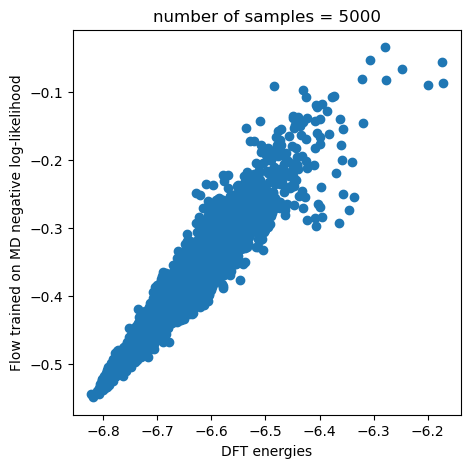

In [163]:
# flow that has been trained by MD 

n_sampless = np.array([100, 250, 500, 1000, 2500, 3300, 5000]).astype(int)

dic_results_BARs = {}
for isomer_id in mode_labels:
    kind = 'flow_dft_samples'

    prop_samples, prop_energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed for proposal:', prop_energy_target.shape[0])
    runs = adaptive_dft_dics[isomer_id]['dict_flows_training']
    model = runs[-2][0]['models'][-1]
   
    print('Number of dft computed for proposal:', mc_energy_target.shape[0])

    kind = 'mcmc_dft_samples'
    mc_samples, mc_energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed for adpative MCMC:', energy_target.shape[0])

    prop = model

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Number of samples used')
    plt.ylabel(r' $\beta \Delta F$') 
    plt.xscale('log')

    dic_results_BARs[isomer_id] = {}
    dic_results_BARs[isomer_id]['means'] = []
    dic_results_BARs[isomer_id]['stds'] = []

    for nn, n_samples in enumerate(n_sampless):
        log_ratio_0_BARs = []
        log_err_0_BARs = []

        n_trial = energy_target.shape[0] // n_samples
        perm = np.random.permutation(energy_target.shape[0])
        for trial in range(n_trial):
            idx = perm[trial*n_samples:(trial+1)*n_samples]
            logprop_prop = - prop.nll(prop_samples[idx]).detach().numpy() 
            logprop_mc = - prop.nll(mc_samples[idx]).detach().numpy() 
            logtgt_prop = - beta * prop_energy_target[idx].detach().numpy()
            logtgt_mc = - beta * mc_energy_target[idx].detach().numpy()


            logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
                                        maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
            log_ratio_0_BARs.append(logr)
            log_err_0_BARs.append(logr_err)

            
        dic_results_BARs[isomer_id]['means'].append(np.array(log_ratio_0_BARs).mean())
        dic_results_BARs[isomer_id]['stds'].append(np.array(log_ratio_0_BARs).std())

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_BARs))*n_samples, log_ratio_0_BARs, marker='x', c='C0', alpha=0.2)
        plt.scatter(n_samples, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')

        
    plt.figure(figsize=(5, 5))
    ax2 = plt.subplot(1,1,1)
    plt.sca(ax2)
    plt.scatter(- logtgt_prop / beta, - logprop_prop / beta)
    plt.xlabel('DFT energies')
    plt.ylabel('Flow trained on MD negative log-likelihood')
    plt.title('number of samples = {:d}'.format(n_samples))


    # max = torch.max(logr_per_sample).item()
    # plt.sca(ax1)
    # plt.plot(n_sampless, np.log(n_sampless)-max, c='k', ls=':', alpha=0.5, label='log(n_samples) - max(logr)')
    # plt.legend()
    

# Saving for combined plot
dic_results_BARs_flow_dft = dic_results_BARs
dic_results_BARs_flow_dft['n_samples'] = n_sampless

### 2.3 Adaptive flow trained on DFT+MLP

Number of dft computed for proposal: 10000
Number of dft computed for adpative-MLP MCMC: 30000
Number of dft computed for proposal: 10000
Number of dft computed for adpative-MLP MCMC: 30000


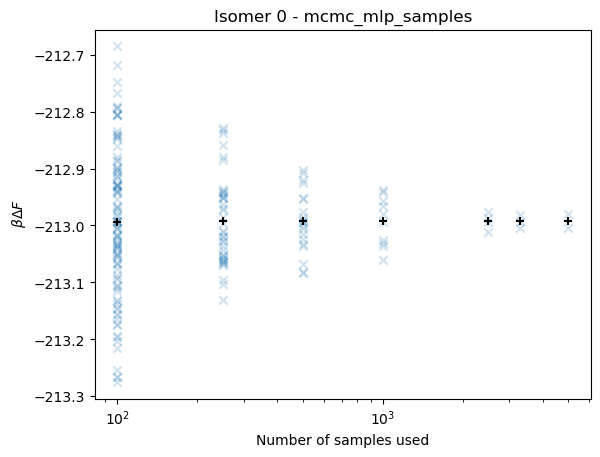

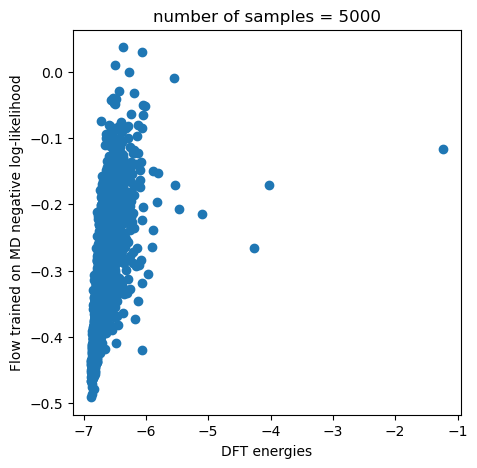

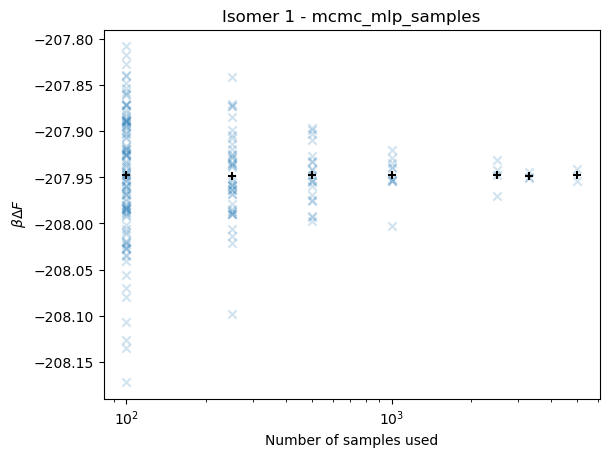

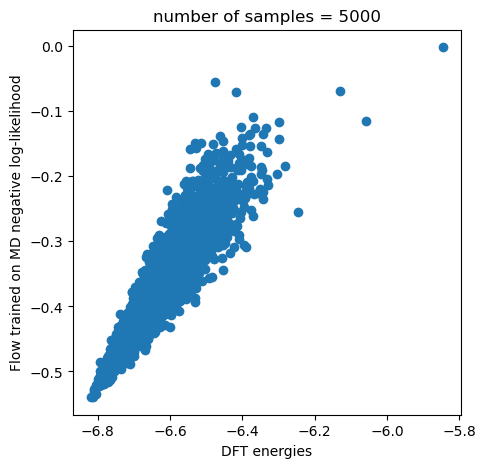

In [164]:
n_sampless = np.array([100, 250, 500, 1000, 2500, 3300, 5000]).astype(int)

dic_results_BARs = {}
for isomer_id in mode_labels:
    kind = 'flow_mlp_samples'

    prop_samples, prop_energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed for proposal:', prop_energy_target.shape[0])
    model = model = adaptive_dft_mlp_dics[isomer_id]['dict_flows_training'][-2][0]['model']

    kind = 'mcmc_mlp_samples'
    mc_samples, mc_energy_target = load_samples_n_energies(kind, isomer_id)
    print('Number of dft computed for adpative-MLP MCMC:', mc_energy_target.shape[0])

    prop = model

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('Number of samples used')
    plt.ylabel(r' $\beta \Delta F$') 
    plt.xscale('log')

    dic_results_BARs[isomer_id] = {}
    dic_results_BARs[isomer_id]['means'] = []
    dic_results_BARs[isomer_id]['stds'] = []

    for nn, n_samples in enumerate(n_sampless):
        log_ratio_0_BARs = []
        log_err_0_BARs = []

        n_trial = energy_target.shape[0] // n_samples
        perm = np.random.permutation(energy_target.shape[0])
        for trial in range(n_trial):
            idx = perm[trial*n_samples:(trial+1)*n_samples]
            logprop_prop = - prop.nll(prop_samples[idx]).detach().numpy() 
            logprop_mc = - prop.nll(mc_samples[idx]).detach().numpy() 
            logtgt_prop = - beta * prop_energy_target[idx].detach().numpy()
            logtgt_mc = - beta * mc_energy_target[idx].detach().numpy()


            logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
                                        maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
            log_ratio_0_BARs.append(logr)
            log_err_0_BARs.append(logr_err)

            
        dic_results_BARs[isomer_id]['means'].append(np.array(log_ratio_0_BARs).mean())
        dic_results_BARs[isomer_id]['stds'].append(np.array(log_ratio_0_BARs).std())

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_BARs))*n_samples, log_ratio_0_BARs, marker='x', c='C0', alpha=0.2)
        plt.scatter(n_samples, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')

        
    plt.figure(figsize=(5, 5))
    ax2 = plt.subplot(1,1,1)
    plt.sca(ax2)
    plt.scatter(- logtgt_prop / beta, - logprop_prop / beta)
    plt.xlabel('DFT energies')
    plt.ylabel('Flow trained on MD negative log-likelihood')
    plt.title('number of samples = {:d}'.format(n_samples))


    # max = torch.max(logr_per_sample).item()
    # plt.sca(ax1)
    # plt.plot(n_sampless, np.log(n_sampless)-max, c='k', ls=':', alpha=0.5, label='log(n_samples) - max(logr)')
    # plt.legend()
    

# Saving for combined plot
dic_results_BARs_flow_dft_mlp = dic_results_BARs
dic_results_BARs_flow_dft_mlp['n_samples'] = n_sampless

### 2.z Combining the plots

Text(0, 0.5, 'Ratio of partition functions')

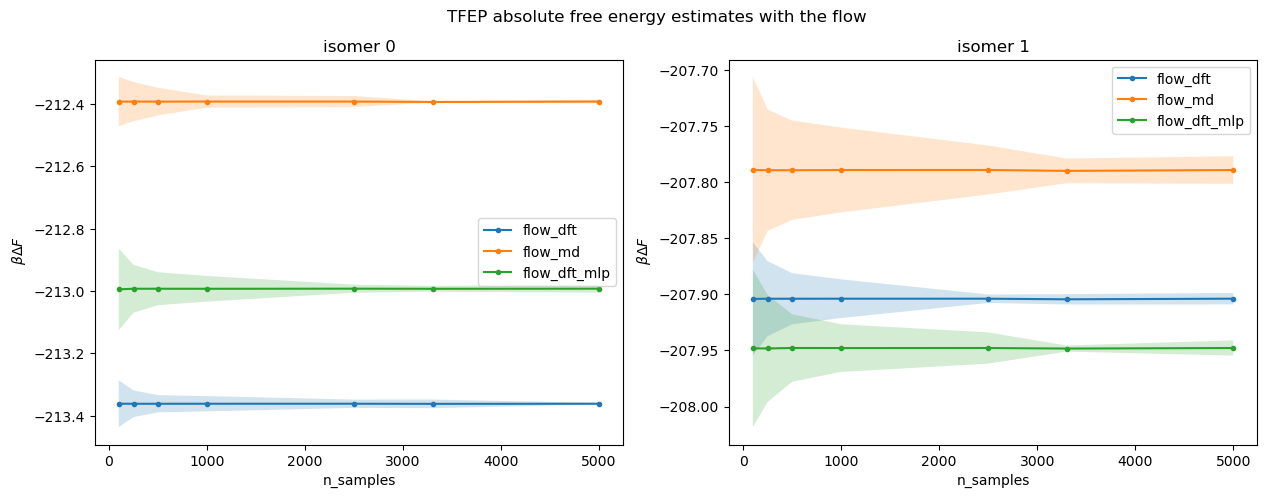

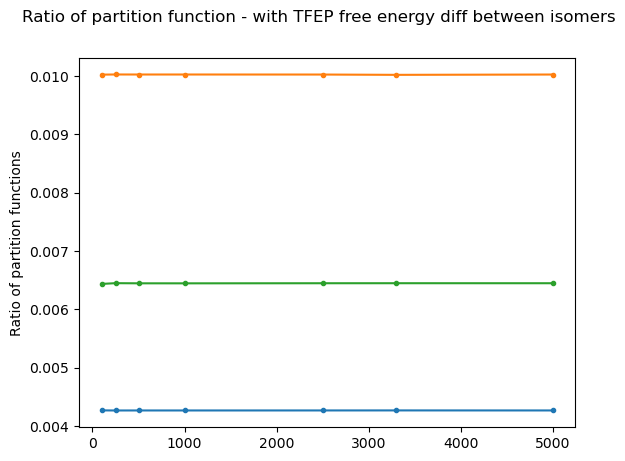

In [ ]:
plt.figure(figsize=(15, 5))
plt.suptitle('TFEP absolute free energy estimates with the flow')
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
for isomer_id in mode_labels:
    plt.sca(axs[isomer_id])
    plt.title('isomer {:d}'.format(isomer_id))

    ############################
    plt.plot(dic_results_BARs_flow_dft['n_samples'],
                dic_results_BARs_flow_dft[isomer_id]['means'],  '.-',
                label='flow_dft')
    plt.fill_between(dic_results_BARs_flow_dft['n_samples'],
                    np.array(dic_results_BARs_flow_dft[isomer_id]['means']) - np.array(dic_results_BARs_flow_dft[isomer_id]['stds']),
                    np.array(dic_results_BARs_flow_dft[isomer_id]['means']) + np.array(dic_results_BARs_flow_dft[isomer_id]['stds']),
                    alpha=0.2)
    ############################
    plt.plot(dic_results_BARs_flow_md['n_samples'], 
                dic_results_BARs_flow_md[isomer_id]['means'], '.-',
                label='flow_md')
    
    plt.fill_between(dic_results_BARs_flow_md['n_samples'],
                    np.array(dic_results_BARs_flow_md[isomer_id]['means']) - np.array(dic_results_BARs_flow_md[isomer_id]['stds']),
                    np.array(dic_results_BARs_flow_md[isomer_id]['means']) + np.array(dic_results_BARs_flow_md[isomer_id]['stds']),
                    alpha=0.2)
    
    ############################
    plt.plot(dic_results_BARs_flow_dft_mlp['n_samples'],
                dic_results_BARs_flow_dft_mlp[isomer_id]['means'],  '.-',
                label='flow_dft_mlp')
    
    plt.fill_between(dic_results_BARs_flow_dft_mlp['n_samples'],
                    np.array(dic_results_BARs_flow_dft_mlp[isomer_id]['means']) - np.array(dic_results_BARs_flow_dft_mlp[isomer_id]['stds']),
                    np.array(dic_results_BARs_flow_dft_mlp[isomer_id]['means']) + np.array(dic_results_BARs_flow_dft_mlp[isomer_id]['stds']),
                    alpha=0.2)
    
    ############################
    plt.plot(dic_results_BARs_flow_dft_mlp_target_mlp['n_samples'],
                dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id]['means'],  '.-',
                label='flow_dft_mlp_target_mlp')
    
    plt.fill_between(dic_results_BARs_flow_dft_mlp_target_mlp['n_samples'],
                    np.array(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id]['means']) - np.array(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id]['stds']),
                    np.array(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id]['means']) + np.array(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id]['stds']),
                    alpha=0.2)

    plt.legend()
    plt.xlabel('n_samples')
    plt.ylabel(r' $\beta \Delta F$') 
    

plt.figure()
plt.suptitle('Ratio of partition function - with TFEP free energy diff between isomers')
plt.plot(dic_results_BARs_flow_dft['n_samples'],
            np.exp( np.array(dic_results_BARs_flow_dft[0]['means']) - np.array(dic_results_BARs_flow_dft[1]['means'])),  '.-',
            label='flow_dft')
plt.plot(dic_results_BARs_flow_md['n_samples'],
            np.exp( np.array(dic_results_BARs_flow_md[0]['means']) - np.array(dic_results_BARs_flow_md[1]['means'])),  '.-',
            label='flow_md')
plt.plot(dic_results_BARs_flow_dft_mlp['n_samples'],
            np.exp( np.array(dic_results_BARs_flow_dft_mlp[0]['means']) - np.array(dic_results_BARs_flow_dft_mlp[1]['means'])),  '.-',
            label='flow_dft_mlp')
plt.plot(dic_results_BARs_flow_dft_mlp_target_mlp['n_samples'],
            np.exp(np.array(dic_results_BARs_flow_dft_mlp_target_mlp[0]['means']) - np.array(dic_results_BARs_flow_dft_mlp_target_mlp[1]['means'])),  '.-',
            label='flow_dft_mlp_target_mlp')
plt.ylabel('Ratio of partition functions')

In [ ]:
# # flow that has been trained by dft 
# kind = 'flow_md_samples'
# # Actually here there is an issue - which is that the configurations are generated from the final flow a priori only
# # n_train_slice = 10
# # train_slice = 10
# # n_samples = 2000
# n_sampless = np.array([100, 250, 500, 1000, 2500, 3300, 5000]).astype(int)

# dic_results_BARs = {}
# for isomer_id in mode_labels:
#     model = md_dics[isomer_id]['model']

#     # train_slices = (np.linspace(0, len(runs)-1, n_train_slice)).astype(int)
#     # models = [runs[t][0]['models'][-1] for t in train_slices]

#     prop_samples, energy_target = load_samples_n_energies(kind, isomer_id)
#     print('Number of dft computed:', energy_target.shape[0])

#     plt.figure()
#     ax1 = plt.subplot(111)
#     plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
#     plt.xlabel('Number of samples used')
#     plt.ylabel(r' $\beta \Delta F$') 
#     plt.xscale('log')

#     dic_results_BARs[isomer_id] = {}
#     dic_results_BARs[isomer_id]['means'] = []
#     dic_results_BARs[isomer_id]['stds'] = []

#     for nn, n_samples in enumerate(n_sampless):
#         log_ratio_0_BARs = []
#         log_err_0_BARs = []

#         n_trial = energy_target.shape[0] // n_samples
#         perm = np.random.permutation(energy_target.shape[0])
#         for trial in range(n_trial):
#             idx = perm[trial*n_samples:(trial+1)*n_samples]
#             # logprob_prop = (- models[t].nll(prop_samples[idx])).detach()
#             logprob_prop = (- model.nll(prop_samples[idx])).detach()
#             logprob_target = (- beta * energy_target[idx]).detach()
#             logr_TFP_0, log_err_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
#             log_ratio_0_BARs.append(logr_TFP_0)
#             log_err_0_BARs.append(log_err_TFP_0)

            
#         dic_results_BARs[isomer_id]['means'].append(np.array(log_ratio_0_BARs).mean())
#         dic_results_BARs[isomer_id]['stds'].append(np.array(log_ratio_0_BARs).std())

#         plt.sca(ax1)
#         plt.scatter(np.ones(len(log_ratio_0_BARs))*n_samples, log_ratio_0_BARs, marker='x', c='C0', alpha=0.2)
#         plt.scatter(n_samples, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')

        
#     plt.figure(figsize=(5, 5))
#     ax2 = plt.subplot(1,1,1)
#     plt.sca(ax2)
#     plt.scatter(- logprob_target / beta, - logprob_prop / beta)
#     plt.xlabel('DFT energies')
#     plt.ylabel('Flow trained on MD negative log-likelihood')
#     plt.title('number of samples = {:d}'.format(n_samples))


#    #Trying to estimate/visualize the variance
#     n_prop = logprob_prop.shape[0]
#     logprob_prop = (- model.nll(prop_samples)).detach()
#     logprob_target = (- beta * energy_target).detach()
#     logr_per_sample = logprob_target - logprob_prop
#     dic_results_BARs[isomer_id]['stds_logr'] = np.std(logr_per_sample.detach().numpy()) / np.sqrt(n_sampless)

#     print(np.std(logr_per_sample.detach().numpy()))
#     plt.figure()
#     plt.hist(logr_per_sample.detach().numpy(), 50, alpha=0.5, label='logr per sample', density=True)
#     plt.xlabel('log ratio of target over prop over samples')

#       # max = torch.max(logr_per_sample).item()
#     # plt.sca(ax1)
#     # plt.plot(n_sampless, np.log(n_sampless)-max, c='k', ls=':', alpha=0.5, label='log(n_samples) - max(logr)')
#     # plt.legend()
    

# # Saving for combined plot
# # dic_results_BARs_flow_md = dic_results_BARs
# # dic_results_BARs_flow_md['n_samples'] = n_sampless

In [18]:
# n_prop = 5

# dic_results_TFPs = {}

# for isomer_id in mode_labels:

#     dic_results_TFPs[isomer_id] = {}
#     dic_results_TFPs[isomer_id]['means'] = []
#     dic_results_TFPs[isomer_id]['stds'] = []

#     plt.figure()
#     plt.title('isomer {:d}'.format(isomer_id))
#     for r,run in enumerate(adaptives_dic[isomer_id]['dict_flows_training']):
#         flow = run[0]['models'][-1]
#         log_ratio_0_TFPs = []
#         log_err_0_TFPs = []

#         for trial in range(10):
#             logr_TFP_0, log_err_TFP_0 = compute_TFP(n_prop, target_log_probs[isomer_id], flow)
#             log_ratio_0_TFPs.append(logr_TFP_0)
#             log_err_0_TFPs.append(log_err_TFP_0)
        
#         dic_results_TFPs[isomer_id][r] = (log_ratio_0_TFPs, log_err_0_TFPs)
        
#         plt.scatter(np.ones(len(log_ratio_0_TFPs))*r, log_ratio_0_TFPs, marker='x', alpha=0.2)
#         plt.scatter(r, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')

#         dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
#         dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
    
#     plt.errorbar(np.arange(len(dic_results_TFPs[isomer_id]['means'])), dic_results_TFPs[isomer_id]['means'], yerr=dic_results_TFPs[isomer_id]['stds'], fmt='o')
       

#     plt.xlabel('adaptive mcmc retraining stage')
#     plt.ylabel('log ratio by Targeted Free energy Perturbation (TFP)')

#     # print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_TFPs).mean(), np.array(log_ratio_0_TFPs).std()))

: 

: 

: 